# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [94]:
%pip install numpy pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

if i had to follow Vonnegut's rules and "keep it simple" i would cut the plot showing "number of estimators".  the training data plot is more intersting because it shows how the model learns as more data is added.  it reveals that there are diminishing returns as you add data which illustrates a fundamental concept in machine learning.   I feel this message us more important/impactful than the message from the "number of estimators"  which is that random forests performance improves slightly and then plateau's.  While this is important i feel its less insightful and more of a tuning detail than a fundamental concept in machine learning.  the "amount of training data used is the more useful parameter to put on the x-axis.

In [95]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [96]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

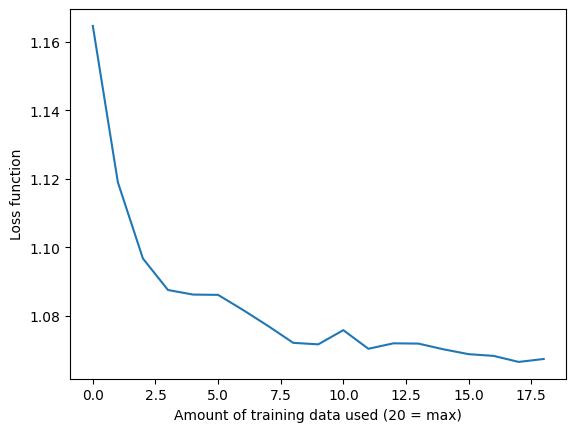

In [97]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [98]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

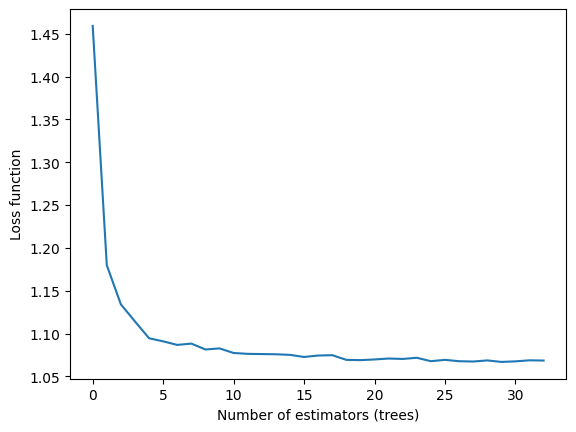

In [99]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [ ]:
accident_df = pd.read_csv("/workspaces/modB2-Week7-milestone/accident.csv")
risk_df = pd.read_csv("/workspaces/modB2-Week7-milestone/National_Risk_Index_Counties.csv")
population_df = pd.read_csv("/workspaces/modB2-Week7-milestone/PopulationEstimates.csv", encoding="latin-1")
poverty_df = pd.read_csv("/workspaces/modB2-Week7-milestone/Poverty2023.csv")

print("Accident:", accident_df.shape)
print("Risk:", risk_df.shape)
print("Population:", population_df.shape)
print("Poverty:", poverty_df.shape)

Accident: (39422, 80)
Risk: (3231, 468)
Population: (208225, 5)
Poverty: (79961, 5)


In [137]:
print("Accident columns:")
print(accident_df.columns.tolist())

print("\nRisk columns:")
print(risk_df.columns.tolist())

print("\nPopulation columns:")
print(population_df.columns.tolist())

print("\nPoverty columns:")
print(poverty_df.columns.tolist())

print("\nAccident sample:")
display(accident_df.head())

print("\nRisk sample:")
display(risk_df.head())

print("\nPopulation sample:")
display(population_df.head())

print("\nPoverty sample:")
display(poverty_df.head())

Accident columns:
['STATE', 'STATENAME', 'ST_CASE', 'PEDS', 'PERNOTMVIT', 'VE_TOTAL', 'VE_FORMS', 'PVH_INVL', 'PERSONS', 'PERMVIT', 'COUNTY', 'COUNTYNAME', 'CITY', 'CITYNAME', 'MONTH', 'MONTHNAME', 'DAY', 'DAYNAME', 'DAY_WEEK', 'DAY_WEEKNAME', 'YEAR', 'HOUR', 'HOURNAME', 'MINUTE', 'MINUTENAME', 'TWAY_ID', 'TWAY_ID2', 'ROUTE', 'ROUTENAME', 'RUR_URB', 'RUR_URBNAME', 'FUNC_SYS', 'FUNC_SYSNAME', 'RD_OWNER', 'RD_OWNERNAME', 'NHS', 'NHSNAME', 'SP_JUR', 'SP_JURNAME', 'MILEPT', 'MILEPTNAME', 'LATITUDE', 'LATITUDENAME', 'LONGITUD', 'LONGITUDNAME', 'HARM_EV', 'HARM_EVNAME', 'MAN_COLL', 'MAN_COLLNAME', 'RELJCT1', 'RELJCT1NAME', 'RELJCT2', 'RELJCT2NAME', 'TYP_INT', 'TYP_INTNAME', 'REL_ROAD', 'REL_ROADNAME', 'WRK_ZONE', 'WRK_ZONENAME', 'LGT_COND', 'LGT_CONDNAME', 'WEATHER', 'WEATHERNAME', 'SCH_BUS', 'SCH_BUSNAME', 'RAIL', 'RAILNAME', 'NOT_HOUR', 'NOT_HOURNAME', 'NOT_MIN', 'NOT_MINNAME', 'ARR_HOUR', 'ARR_HOURNAME', 'ARR_MIN', 'ARR_MINNAME', 'HOSP_HR', 'HOSP_HRNAME', 'HOSP_MN', 'HOSP_MNNAME', 'FATALS

,STATE,STATENAME,ST_CASE,PEDS,PERNOTMVIT,VE_TOTAL,VE_FORMS,PVH_INVL,PERSONS,PERMVIT,...,ARR_HOURNAME,ARR_MIN,ARR_MINNAME,HOSP_HR,HOSP_HRNAME,HOSP_MN,HOSP_MNNAME,FATALS,FIPS,alcohol_flag
0,01,Alabama,10001,0,0,2,2,0,3,3,...,1:00pm-1:59pm,4,4,13,1:00pm-1:59pm,47,47,1,01107,0.0
1,01,Alabama,10002,0,0,2,2,0,5,5,...,Unknown EMS Scene Arrival Hour,99,Unknown EMS Scene Arrival Minutes,99,Unknown,99,Unknown EMS Hospital Arrival Time,2,01101,0.0
2,01,Alabama,10003,0,0,1,1,0,2,2,...,1:00am-1:59am,50,50,99,Unknown,99,Unknown EMS Hospital Arrival Time,1,01115,0.0
3,01,Alabama,10004,0,0,1,1,0,1,1,...,3:00pm-3:59pm,9,9,15,3:00pm-3:59pm,44,44,1,01101,0.0
4,01,Alabama,10005,1,1,1,1,0,1,1,...,6:00pm-6:59pm,54,54,88,Not Applicable (Not Transported),88,Not Applicable (Not Transported),1,01073,0.0



Risk sample:


,OBJECTID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,GlobalID,SHAPE_Length,SHAPE_Area
0,1,C01001,Alabama,AL,1,Autauga,County,1,1001,58764,...,7.410082e-09,8.725777e-06,10.461158,8494.906508,12.217626,Very Low,March 2023,{3AD9CFD6-777A-4402-B626-078B58021509},2.066038,0.150256
1,2,C01003,Alabama,AL,1,Baldwin,County,3,1003,231365,...,2.287120e-08,1.548360e-07,13.339523,65619.701638,52.083996,Relatively Low,March 2023,{FA12370E-EDD0-4202-9570-793CD2970144},7.732268,0.397498
2,3,C01005,Alabama,AL,1,Barbour,County,5,1005,25160,...,2.347236e-08,7.606598e-07,16.125039,15501.730335,19.535476,Very Low,March 2023,{DC687EC0-E0DB-43FB-BF00-B3EBC0C0C500},2.695263,0.223270
3,4,C01007,Alabama,AL,1,Bibb,County,7,1007,22239,...,1.270300e-08,1.202015e-05,16.991643,7496.186940,11.104041,Very Low,March 2023,{66DBC069-7288-425F-B6FC-FDB36D3A61EF},1.887521,0.156473
4,5,C01009,Alabama,AL,1,Blount,County,9,1009,58992,...,1.482016e-08,2.002965e-07,12.039616,17175.160729,21.444480,Very Low,March 2023,{D72E91D2-0CBC-4425-9995-BFABD120F908},2.423552,0.164406



Population sample:


,FIPStxt,State,Area_Name,Attribute,Value
0,0,US,United States,CENSUS_2020_POP,331449281.0
1,0,US,United States,ESTIMATES_BASE_2020,331464948.0
2,0,US,United States,POP_ESTIMATE_2020,331526933.0
3,0,US,United States,POP_ESTIMATE_2021,332048977.0
4,0,US,United States,POP_ESTIMATE_2022,333271411.0



Poverty sample:


,FIPS_Code,Stabr,Area_Name,Attribute,Value
0,0,US,United States,POVALL_2023,40763043.0
1,0,US,United States,CI90LBALL_2023,40485829.0
2,0,US,United States,CI90UBALL_2023,41040257.0
3,0,US,United States,PCTPOVALL_2023,12.5
4,0,US,United States,CI90LBALLP_2023,12.4


In [138]:
print("Population Attribute values:")
print(sorted(population_df["Attribute"].dropna().unique()))

print("\nPoverty Attribute values:")
print(sorted(poverty_df["Attribute"].dropna().unique()))

Population Attribute values:
['BIRTHS_2020', 'BIRTHS_2021', 'BIRTHS_2022', 'BIRTHS_2023', 'CENSUS_2020_POP', 'DEATHS_2020', 'DEATHS_2021', 'DEATHS_2022', 'DEATHS_2023', 'DOMESTIC_MIG_2020', 'DOMESTIC_MIG_2021', 'DOMESTIC_MIG_2022', 'DOMESTIC_MIG_2023', 'ESTIMATES_BASE_2020', 'Economic_typology_2015', 'GQ_ESTIMATES_2020', 'GQ_ESTIMATES_2021', 'GQ_ESTIMATES_2022', 'GQ_ESTIMATES_2023', 'GQ_ESTIMATES_BASE_2020', 'INTERNATIONAL_MIG_2020', 'INTERNATIONAL_MIG_2021', 'INTERNATIONAL_MIG_2022', 'INTERNATIONAL_MIG_2023', 'NATURAL_CHG_2020', 'NATURAL_CHG_2021', 'NATURAL_CHG_2022', 'NATURAL_CHG_2023', 'NET_MIG_2020', 'NET_MIG_2021', 'NET_MIG_2022', 'NET_MIG_2023', 'N_POP_CHG_2020', 'N_POP_CHG_2021', 'N_POP_CHG_2022', 'N_POP_CHG_2023', 'POP_ESTIMATE_2020', 'POP_ESTIMATE_2021', 'POP_ESTIMATE_2022', 'POP_ESTIMATE_2023', 'RESIDUAL_2020', 'RESIDUAL_2021', 'RESIDUAL_2022', 'RESIDUAL_2023', 'R_BIRTH_2021', 'R_BIRTH_2022', 'R_BIRTH_2023', 'R_DEATH_2021', 'R_DEATH_2022', 'R_DEATH_2023', 'R_DOMESTIC_MIG_2021

In [139]:
print("Population Attribute counts:")
display(population_df["Attribute"].value_counts(dropna=False))

print("\nPoverty Attribute counts:")
display(poverty_df["Attribute"].value_counts(dropna=False))

Population Attribute counts:


Attribute
ESTIMATES_BASE_2020       3275
POP_ESTIMATE_2020         3275
POP_ESTIMATE_2021         3275
POP_ESTIMATE_2022         3275
POP_ESTIMATE_2023         3275
                          ... 
GQ_ESTIMATES_2020         3195
GQ_ESTIMATES_2021         3195
GQ_ESTIMATES_2022         3195
GQ_ESTIMATES_2023         3195
Economic_typology_2015    3141
Name: count, Length: 65, dtype: int64


Poverty Attribute counts:


Attribute
POVALL_2023                        3195
CI90LBALL_2023                     3195
CI90UBALL_2023                     3195
PCTPOVALL_2023                     3195
CI90LBALLP_2023                    3195
CI90UBALLP_2023                    3195
POV017_2023                        3195
CI90LB017_2023                     3195
CI90UB017_2023                     3195
PCTPOV017_2023                     3195
CI90LB017P_2023                    3195
CI90UB017P_2023                    3195
POV517_2023                        3195
CI90LB517_2023                     3195
CI90UB517_2023                     3195
PCTPOV517_2023                     3195
CI90LB517P_2023                    3195
CI90UB517P_2023                    3195
MEDHHINC_2023                      3195
CI90LBINC_2023                     3195
CI90UBINC_2023                     3195
Rural_Urban_Continuum_Code_2023    3144
Urban_Influence_Code_2024          3144
Rural_Urban_Continuum_Code_2013    3133
Urban_Influence_Code_2013     

In [142]:
population_clean = population_df[
    population_df["Attribute"] == "POP_ESTIMATE_2022"].copy()

population_clean = population_clean.rename(columns={
    "FIPStxt": "FIPS",
    "Value": "population"})

population_clean["FIPS"] = population_clean["FIPS"].astype(str).str.zfill(5)

population_clean = population_clean[
    (population_clean["FIPS"].str.len() == 5) &
    (population_clean["FIPS"].str[2:] != "000")]

display(population_clean.head())
print("Population rows:", population_clean.shape)

,FIPS,State,Area_Name,Attribute,population
125,01001,AL,Autauga County,POP_ESTIMATE_2022,59726.0
190,01003,AL,Baldwin County,POP_ESTIMATE_2022,246531.0
255,01005,AL,Barbour County,POP_ESTIMATE_2022,24700.0
320,01007,AL,Bibb County,POP_ESTIMATE_2022,21986.0
385,01009,AL,Blount County,POP_ESTIMATE_2022,59516.0


Population rows: (3222, 5)


In [143]:
poverty_clean = poverty_df[poverty_df["Attribute"] == "PCTPOVALL_2023"].copy()

poverty_clean = poverty_clean.rename(columns={
    "FIPS_Code": "FIPS",
    "Value": "poverty_rate"})

poverty_clean["FIPS"] = poverty_clean["FIPS"].astype(str).str.zfill(5)

poverty_clean = poverty_clean[
    (poverty_clean["FIPS"].str.len() == 5) &
    (poverty_clean["FIPS"].str[2:] != "000")]

display(poverty_clean.head())
print("Poverty rows:", poverty_clean.shape)

,FIPS,Stabr,Area_Name,Attribute,poverty_rate
61,01001,AL,Autauga County,PCTPOVALL_2023,11.7
86,01003,AL,Baldwin County,PCTPOVALL_2023,10.0
111,01005,AL,Barbour County,PCTPOVALL_2023,25.5
136,01007,AL,Bibb County,PCTPOVALL_2023,19.4
161,01009,AL,Blount County,PCTPOVALL_2023,12.8


Poverty rows: (3143, 5)


In [144]:
risk_clean = risk_df[[
    "STCOFIPS",
    "RISK_SCORE",
    "SOVI_SCORE",
    "RESL_SCORE"]].copy()

risk_clean = risk_clean.rename(columns={
    "STCOFIPS": "FIPS"})

risk_clean["FIPS"] = risk_clean["FIPS"].astype(str).str.zfill(5)

display(risk_clean.head())

,FIPS,RISK_SCORE,SOVI_SCORE,RESL_SCORE
0,01001,49.220490,51.299999,51.810001
1,01003,97.709195,31.030001,86.120003
2,01005,56.188355,99.269997,6.240000
3,01007,32.484887,80.779999,19.730000
4,01009,65.128858,51.369999,22.820000


In [145]:
accident_df["STATE"] = accident_df["STATE"].astype(str).str.zfill(2)
accident_df["COUNTY"] = accident_df["COUNTY"].astype(str).str.zfill(3)

# Create five digit FIPS
accident_df["FIPS"] = accident_df["STATE"] + accident_df["COUNTY"]

display(accident_df[["STATE", "COUNTY", "FIPS"]].head())

,STATE,COUNTY,FIPS
0,01,107,01107
1,01,101,01101
2,01,115,01115
3,01,101,01101
4,01,073,01073


In [146]:
county_df = (
    accident_df
    .groupby("FIPS", as_index=False)
    .agg({
        "FATALS": "sum",       # total fatalities per county
        "PERSONS": "mean",
        "VE_TOTAL": "mean",
        "PEDS": "mean",
        "PERNOTMVIT": "mean",
        "PERMVIT": "mean"
    }))

print("County df shape:", county_df.shape)
display(county_df.head())

County df shape: (2844, 7)


,FIPS,FATALS,PERSONS,VE_TOTAL,PEDS,PERNOTMVIT,PERMVIT
0,01001,10,2.222222,1.666667,0.111111,0.111111,2.222222
1,01003,33,2.133333,1.766667,0.233333,0.266667,2.100000
2,01005,1,1.000000,1.000000,0.000000,0.000000,1.000000
3,01007,2,1.000000,1.000000,0.000000,0.000000,1.000000
4,01009,12,2.166667,1.666667,0.083333,0.083333,2.166667


In [147]:
df = county_df.merge(population_clean, on="FIPS", how="inner")
df = df.merge(poverty_clean, on="FIPS", how="left")
df = df.merge(risk_clean, on="FIPS", how="left")

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (2833, 18)


,FIPS,FATALS,PERSONS,VE_TOTAL,PEDS,PERNOTMVIT,PERMVIT,State,Area_Name_x,Attribute_x,population,Stabr,Area_Name_y,Attribute_y,poverty_rate,RISK_SCORE,SOVI_SCORE,RESL_SCORE
0,01001,10,2.222222,1.666667,0.111111,0.111111,2.222222,AL,Autauga County,POP_ESTIMATE_2022,59726.0,AL,Autauga County,PCTPOVALL_2023,11.7,49.220490,51.299999,51.810001
1,01003,33,2.133333,1.766667,0.233333,0.266667,2.100000,AL,Baldwin County,POP_ESTIMATE_2022,246531.0,AL,Baldwin County,PCTPOVALL_2023,10.0,97.709195,31.030001,86.120003
2,01005,1,1.000000,1.000000,0.000000,0.000000,1.000000,AL,Barbour County,POP_ESTIMATE_2022,24700.0,AL,Barbour County,PCTPOVALL_2023,25.5,56.188355,99.269997,6.240000
3,01007,2,1.000000,1.000000,0.000000,0.000000,1.000000,AL,Bibb County,POP_ESTIMATE_2022,21986.0,AL,Bibb County,PCTPOVALL_2023,19.4,32.484887,80.779999,19.730000
4,01009,12,2.166667,1.666667,0.083333,0.083333,2.166667,AL,Blount County,POP_ESTIMATE_2022,59516.0,AL,Blount County,PCTPOVALL_2023,12.8,65.128858,51.369999,22.820000


In [148]:
df = county_df.merge(population_clean, on="FIPS", how="inner")
df = df.merge(poverty_clean, on="FIPS", how="left")
df = df.merge(risk_clean, on="FIPS", how="left")

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (2833, 18)


,FIPS,FATALS,PERSONS,VE_TOTAL,PEDS,PERNOTMVIT,PERMVIT,State,Area_Name_x,Attribute_x,population,Stabr,Area_Name_y,Attribute_y,poverty_rate,RISK_SCORE,SOVI_SCORE,RESL_SCORE
0,01001,10,2.222222,1.666667,0.111111,0.111111,2.222222,AL,Autauga County,POP_ESTIMATE_2022,59726.0,AL,Autauga County,PCTPOVALL_2023,11.7,49.220490,51.299999,51.810001
1,01003,33,2.133333,1.766667,0.233333,0.266667,2.100000,AL,Baldwin County,POP_ESTIMATE_2022,246531.0,AL,Baldwin County,PCTPOVALL_2023,10.0,97.709195,31.030001,86.120003
2,01005,1,1.000000,1.000000,0.000000,0.000000,1.000000,AL,Barbour County,POP_ESTIMATE_2022,24700.0,AL,Barbour County,PCTPOVALL_2023,25.5,56.188355,99.269997,6.240000
3,01007,2,1.000000,1.000000,0.000000,0.000000,1.000000,AL,Bibb County,POP_ESTIMATE_2022,21986.0,AL,Bibb County,PCTPOVALL_2023,19.4,32.484887,80.779999,19.730000
4,01009,12,2.166667,1.666667,0.083333,0.083333,2.166667,AL,Blount County,POP_ESTIMATE_2022,59516.0,AL,Blount County,PCTPOVALL_2023,12.8,65.128858,51.369999,22.820000


In [149]:
df["fatalities_per_100k"] = (df["FATALS"] / df["population"]) * 100000

df = df.replace([float("inf"), -float("inf")], None)

print(df["fatalities_per_100k"].describe())

count     2833.000000
mean        34.771962
std        385.802618
min          1.711757
25%         11.424241
50%         18.477031
75%         30.528137
max      20454.545455
Name: fatalities_per_100k, dtype: float64


In [150]:
model_cols = [
    "PERSONS",
    "VE_TOTAL",
    "PEDS",
    "PERNOTMVIT",
    "PERMVIT",
    "poverty_rate",
    "RISK_SCORE",
    "SOVI_SCORE",
    "RESL_SCORE"]

df_model = df[model_cols + ["fatalities_per_100k"]].dropna()

X = df_model[model_cols]
y = df_model["fatalities_per_100k"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2833, 9)
y shape: (2833,)


In [152]:
# Filter before selecting model columns
df_filtered = df[
    (df["population"] > 1000) &
    (df["fatalities_per_100k"] < 200)].copy()

model_cols = [
    "PERSONS",
    "VE_TOTAL",
    "PEDS",
    "PERNOTMVIT",
    "PERMVIT",
    "poverty_rate",
    "RISK_SCORE",
    "SOVI_SCORE",
    "RESL_SCORE"]

df_model = df_filtered[model_cols + ["fatalities_per_100k"]].dropna().copy()

X = df_model[model_cols]
y = df_model["fatalities_per_100k"]

print("Filtered df shape:", df_filtered.shape)
print("Model df shape:", df_model.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print(df_model["fatalities_per_100k"].describe())

Filtered df shape: (2805, 19)
Model df shape: (2805, 10)
X shape: (2805, 9)
y shape: (2805,)
count    2805.000000
mean       24.778189
std        22.237374
min         1.711757
25%        11.357828
50%        18.385733
75%        29.887424
max       193.423598
Name: fatalities_per_100k, dtype: float64


In [153]:
# Start from the merged dataframe (not df_model)
df_filtered = df[
    (df["population"] > 1000) &
    (df["fatalities_per_100k"] < 200)].copy()

model_cols = [
    "PERSONS",
    "VE_TOTAL",
    "PEDS",
    "PERNOTMVIT",
    "PERMVIT",
    "poverty_rate",
    "RISK_SCORE",
    "SOVI_SCORE",
    "RESL_SCORE"]

df_model = df_filtered[model_cols + ["fatalities_per_100k"]].dropna().copy()

X = df_model[model_cols]
y = df_model["fatalities_per_100k"]

print("Filtered df shape:", df_filtered.shape)
print("Model df shape:", df_model.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print(df_model["fatalities_per_100k"].describe())

Filtered df shape: (2805, 19)
Model df shape: (2805, 10)
X shape: (2805, 9)
y shape: (2805,)
count    2805.000000
mean       24.778189
std        22.237374
min         1.711757
25%        11.357828
50%        18.385733
75%        29.887424
max       193.423598
Name: fatalities_per_100k, dtype: float64


In [154]:
print(df.columns.tolist())
print(df_model.columns.tolist())

['FIPS', 'FATALS', 'PERSONS', 'VE_TOTAL', 'PEDS', 'PERNOTMVIT', 'PERMVIT', 'State', 'Area_Name_x', 'Attribute_x', 'population', 'Stabr', 'Area_Name_y', 'Attribute_y', 'poverty_rate', 'RISK_SCORE', 'SOVI_SCORE', 'RESL_SCORE', 'fatalities_per_100k']
['PERSONS', 'VE_TOTAL', 'PEDS', 'PERNOTMVIT', 'PERMVIT', 'poverty_rate', 'RISK_SCORE', 'SOVI_SCORE', 'RESL_SCORE', 'fatalities_per_100k']


In [155]:
df = df.drop(columns=[
    'State', 'Area_Name_x', 'Area_Name_y',
    'Attribute_x', 'Attribute_y', 'Stabr'
], errors='ignore')

In [156]:
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, make_scorer
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# baseline model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Baseline R^2:", r2_score(y_test, y_pred))
print("Baseline MAE:", mean_absolute_error(y_test, y_pred))

Baseline R^2: 0.3128567833252861
Baseline MAE: 12.379139855103757


In [119]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2")

print("CV R^2 scores:", cv_scores)
print("Mean CV R^2:", cv_scores.mean())

CV R^2 scores: [0.2113114  0.16579035 0.32504281 0.20476666 0.21127571]
Mean CV R^2: 0.22363738811166103


In [ ]:
def corr_score(y_true, y_pred):
    return np.corrcoef(y_true, y_pred)[0, 1]

corr_scorer = make_scorer(corr_score)

param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 1.0]}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}


In [121]:
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)

print("Test R^2:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test correlation:", np.corrcoef(y_test, y_pred)[0, 1])

Test R^2: 0.3254745007042664
Test MAE: 11.98253995721202
Test correlation: 0.5831021732983


In [ ]:
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_}).sort_values("importance", ascending=False)

print(feature_importance_df)

        feature  importance
8    RESL_SCORE    0.279639
6    RISK_SCORE    0.191362
7    SOVI_SCORE    0.121768
5  poverty_rate    0.115333
0       PERSONS    0.083086
4       PERMVIT    0.080244
1      VE_TOTAL    0.070010
2          PEDS    0.032987
3    PERNOTMVIT    0.025571


In [ ]:
corr = df_common.corr(numeric_only=True)

print(corr.loc[
    ["PERSONS", "PERMVIT", "PEDS", "PERNOTMVIT"],
    ["PERSONS", "PERMVIT", "PEDS", "PERNOTMVIT"]])

             PERSONS   PERMVIT      PEDS  PERNOTMVIT
PERSONS     1.000000  0.997741 -0.098250   -0.075874
PERMVIT     0.997741  1.000000 -0.100258   -0.095278
PEDS       -0.098250 -0.100258  1.000000    0.965577
PERNOTMVIT -0.075874 -0.095278  0.965577    1.000000


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model_cols_original = [
    "PERSONS",
    "VE_TOTAL",
    "PEDS",
    "PERNOTMVIT",
    "PERMVIT",
    "poverty_rate",
    "RISK_SCORE",
    "SOVI_SCORE",
    "RESL_SCORE"]

model_cols_clean = [
    "PERSONS",
    "VE_TOTAL",
    "PEDS",
    "poverty_rate",
    "RISK_SCORE",
    "SOVI_SCORE",
    "RESL_SCORE"]

feature_sets = {
    "ORIGINAL (with redundancy)": model_cols_original,
    "CLEAN (reduced multicollinearity)": model_cols_clean}

# BUILD COMMON DATASET
all_cols = list(set(model_cols_original + ["fatalities_per_100k"]))
df_common = df_corrected[all_cols].dropna().copy()

print("Common dataset shape:", df_common.shape)

y = df_common["fatalities_per_100k"]

results = {}

for label, cols in feature_sets.items():

    print(label)

    X = df_common[cols]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    # Baseline model
    rf = RandomForestRegressor(random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print("Baseline R^2:", r2_score(y_test, y_pred))
    print("Baseline MAE:", mean_absolute_error(y_test, y_pred))
    print("Baseline correlation:", np.corrcoef(y_test, y_pred)[0, 1])

    # CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf, X, y, cv=kf, scoring="r2")

    print("CV R^2 scores:", cv_scores)
    print("Mean CV R^2:", cv_scores.mean())

    # hyperparameter tuning

    param_dist = {
        "n_estimators": [50, 100, 200, 300],
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5, 1.0]}

    search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        param_distributions=param_dist,
        n_iter=20,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        random_state=42,
        verbose=0)

    search.fit(X_train, y_train)

    best_rf = search.best_estimator_
    y_pred_best = best_rf.predict(X_test)

    print("Best params:", search.best_params_)
    print("Test R^2:", r2_score(y_test, y_pred_best))
    print("Test MAE:", mean_absolute_error(y_test, y_pred_best))
    print("Test correlation:", np.corrcoef(y_test, y_pred_best)[0, 1])

    # FEATURE IMPORTANCE
    feature_importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": best_rf.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nFeature Importance:")
    print(feature_importance_df)

    results[label] = {
        "R2": r2_score(y_test, y_pred_best),
        "MAE": mean_absolute_error(y_test, y_pred_best),
        "Corr": np.corrcoef(y_test, y_pred_best)[0, 1]}

# FINAL COMPARISON

print("FINAL COMPARISON")

for label, vals in results.items():
    print(
        f"{label}: "
        f"R^2={vals['R2']:.3f}, "
        f"MAE={vals['MAE']:.3f}, "
        f"Corr={vals['Corr']:.3f}")

Common dataset shape: (2805, 10)
ORIGINAL (with redundancy)
Baseline R^2: 0.3128567833252861
Baseline MAE: 12.379139855103757
Baseline correlation: 0.5598649939848316
CV R^2 scores: [0.29792486 0.22359774 0.26622872 0.20317956 0.22056684]
Mean CV R^2: 0.24229954408563364
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Test R^2: 0.3254745007042664
Test MAE: 11.98253995721202
Test correlation: 0.5831021732983

Feature Importance:
        feature  importance
8    RESL_SCORE    0.279639
6    RISK_SCORE    0.191362
7    SOVI_SCORE    0.121768
5  poverty_rate    0.115333
0       PERSONS    0.083086
4       PERMVIT    0.080244
1      VE_TOTAL    0.070010
2          PEDS    0.032987
3    PERNOTMVIT    0.025571
CLEAN (reduced multicollinearity)
Baseline R^2: 0.3149649754829088
Baseline MAE: 12.402333928181386
Baseline correlation: 0.5617934823755096
CV R^2 scores: [0.31062594 0.22021618 0.26631067 0.1929446  0.22759368

In [158]:
person_df = pd.read_csv(
    "/workspaces/modB2-Week7-milestone/person.csv",
    encoding="latin-1",
    low_memory=False)

print(person_df.shape)
print(person_df.columns.tolist())

(96186, 126)
['STATE', 'STATENAME', 'ST_CASE', 'VEH_NO', 'PER_NO', 'VE_FORMS', 'COUNTY', 'MONTH', 'MONTHNAME', 'DAY', 'DAYNAME', 'HOUR', 'HOURNAME', 'MINUTE', 'MINUTENAME', 'HARM_EV', 'HARM_EVNAME', 'MAN_COLL', 'MAN_COLLNAME', 'SCH_BUS', 'SCH_BUSNAME', 'MOD_YEAR', 'MOD_YEARNAME', 'VPICMAKE', 'VPICMAKENAME', 'VPICMODEL', 'VPICMODELNAME', 'VPICBODYCLASS', 'VPICBODYCLASSNAME', 'MAKE', 'MAKENAME', 'BODY_TYP', 'BODY_TYPNAME', 'ICFINALBODY', 'ICFINALBODYNAME', 'GVWR_FROM', 'GVWR_FROMNAME', 'GVWR_TO', 'GVWR_TONAME', 'TOW_VEH', 'TOW_VEHNAME', 'AGE', 'AGENAME', 'SEX', 'SEXNAME', 'PER_TYP', 'PER_TYPNAME', 'INJ_SEV', 'INJ_SEVNAME', 'SEAT_POS', 'SEAT_POSNAME', 'REST_USE', 'REST_USENAME', 'REST_MIS', 'REST_MISNAME', 'HELM_USE', 'HELM_USENAME', 'HELM_MIS', 'HELM_MISNAME', 'AIR_BAG', 'AIR_BAGNAME', 'EJECTION', 'EJECTIONNAME', 'EJ_PATH', 'EJ_PATHNAME', 'EXTRICAT', 'EXTRICATNAME', 'DRINKING', 'DRINKINGNAME', 'ALC_STATUS', 'ALC_STATUSNAME', 'ATST_TYP', 'ATST_TYPNAME', 'ALC_RES', 'ALC_RESNAME', 'DRUGS', 

In [159]:
print(person_df["DRINKING"].value_counts(dropna=False))
print(person_df[["DRINKING", "DRINKINGNAME"]].drop_duplicates().sort_values("DRINKING"))

DRINKING
8    39703
0    35819
9    11184
1     9480
Name: count, dtype: int64
    DRINKING               DRINKINGNAME
0          0  No (Alcohol Not Involved)
36         1     Yes (Alcohol Involved)
2          8               Not Reported
3          9        Reported as Unknown


In [171]:
# keep only needed columns
person_subset = person_df[["ST_CASE", "DRINKING"]].copy()

# keep only valid values
person_subset = person_subset[person_subset["DRINKING"].isin([0, 1])]

# create binary flag
person_subset["alcohol_flag"] = person_subset["DRINKING"]

In [172]:
alcohol_by_crash = (
    person_subset
    .groupby("ST_CASE")["alcohol_flag"]
    .max()
    .reset_index())

print(alcohol_by_crash.head())
print(alcohol_by_crash["alcohol_flag"].value_counts())

   ST_CASE  alcohol_flag
0    10001             0
1    10004             0
2    10005             0
3    10006             0
4    10008             0
alcohol_flag
0    19370
1     8802
Name: count, dtype: int64


In [175]:
accident_df = pd.read_csv("/workspaces/modB2-Week7-milestone/accident.csv")

# rebuild FIPS
accident_df["STATE"] = accident_df["STATE"].astype(str).str.zfill(2)
accident_df["COUNTY"] = accident_df["COUNTY"].astype(str).str.zfill(3)
accident_df["FIPS"] = accident_df["STATE"] + accident_df["COUNTY"]

# merge alcohol flag once
accident_df = accident_df.merge(
    alcohol_by_crash,
    on="ST_CASE",
    how="left")

accident_df["alcohol_flag"] = accident_df["alcohol_flag"].fillna(0)

In [176]:
county_df_with_alcohol = (
    accident_df
    .groupby("FIPS", as_index=False)
    .agg({
        "FATALS": "sum",
        "PERSONS": "mean",
        "VE_TOTAL": "mean",
        "PEDS": "mean",
        "PERNOTMVIT": "mean",
        "PERMVIT": "mean",
        "alcohol_flag": "mean"}))

print(county_df_with_alcohol.head())

    FIPS  FATALS   PERSONS  VE_TOTAL      PEDS  PERNOTMVIT   PERMVIT  \
0  01001      10  2.222222  1.666667  0.111111    0.111111  2.222222   
1  01003      33  2.133333  1.766667  0.233333    0.266667  2.100000   
2  01005       1  1.000000  1.000000  0.000000    0.000000  1.000000   
3  01007       2  1.000000  1.000000  0.000000    0.000000  1.000000   
4  01009      12  2.166667  1.666667  0.083333    0.083333  2.166667   

   alcohol_flag  
0      0.000000  
1      0.300000  
2      1.000000  
3      0.000000  
4      0.083333  


In [177]:
df_alcohol = county_df_with_alcohol.merge(population_clean, on="FIPS", how="inner")
df_alcohol = df_alcohol.merge(poverty_clean, on="FIPS", how="left")
df_alcohol = df_alcohol.merge(risk_clean, on="FIPS", how="left")

In [178]:
df_alcohol["fatalities_per_100k"] = (df_alcohol["FATALS"] / df_alcohol["population"]) * 100000

df_alcohol = df_alcohol[
    (df_alcohol["population"] > 1000) &
    (df_alcohol["fatalities_per_100k"] < 200)].copy()

In [179]:
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# clean base features
model_cols_clean = [
    "PERSONS",
    "VE_TOTAL",
    "PEDS",
    "poverty_rate",
    "RISK_SCORE",
    "SOVI_SCORE",
    "RESL_SCORE"]

model_cols_with_alcohol = model_cols_clean + ["alcohol_flag"]

feature_sets = {
    "CLEAN BASELINE": model_cols_clean,
    "CLEAN + ALCOHOL": model_cols_with_alcohol}

results = {}

for label, cols in feature_sets.items():

    print(label)

    df_model = df_alcohol[cols + ["fatalities_per_100k"]].dropna().copy()

    X = df_model[cols]
    y = df_model["fatalities_per_100k"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42    )

    rf = RandomForestRegressor(random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print("Baseline R^2:", r2_score(y_test, y_pred))
    print("Baseline MAE:", mean_absolute_error(y_test, y_pred))
    print("Baseline correlation:", np.corrcoef(y_test, y_pred)[0, 1])

    # cv
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf, X, y, cv=kf, scoring="r2")

    print("Mean CV R^2:", cv_scores.mean())

    # hyperparameter tuning
    param_dist = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5]}

    search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        param_dist,
        n_iter=15,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        random_state=42    )

    search.fit(X_train, y_train)

    best_rf = search.best_estimator_
    y_pred_best = best_rf.predict(X_test)

    r2 = r2_score(y_test, y_pred_best)
    mae = mean_absolute_error(y_test, y_pred_best)
    corr = np.corrcoef(y_test, y_pred_best)[0, 1]

    print("Test R^2:", r2)
    print("Test MAE:", mae)
    print("Test correlation:", corr)

    # feature importance
    importances = pd.DataFrame({
        "feature": cols,
        "importance": best_rf.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nFeature importance:")
    print(importances)

    results[label] = {"R2": r2, "MAE": mae, "Corr": corr}

# final summary
print("\nFINAL COMPARISON")
for k, v in results.items():
    print(f"{k}: R²={v['R2']:.3f}, MAE={v['MAE']:.3f}, Corr={v['Corr']:.3f}")

CLEAN BASELINE
Baseline R^2: 0.3149649754829088
Baseline MAE: 12.402333928181386
Baseline correlation: 0.5617934823755096
Mean CV R^2: 0.2435382166790446
Test R^2: 0.32957606651258065
Test MAE: 12.059233534596778
Test correlation: 0.5835129863934441

Feature importance:
        feature  importance
6    RESL_SCORE    0.297244
4    RISK_SCORE    0.207355
5    SOVI_SCORE    0.133618
0       PERSONS    0.125581
3  poverty_rate    0.121548
1      VE_TOTAL    0.074999
2          PEDS    0.039655
CLEAN + ALCOHOL
Baseline R^2: 0.3357383075196648
Baseline MAE: 12.15974695912761
Baseline correlation: 0.5815761333848232
Mean CV R^2: 0.24845813368359412
Test R^2: 0.33236369323018133
Test MAE: 11.870855911162074
Test correlation: 0.5920005667109456

Feature importance:
        feature  importance
6    RESL_SCORE    0.282494
4    RISK_SCORE    0.198078
5    SOVI_SCORE    0.129703
0       PERSONS    0.118088
3  poverty_rate    0.115178
1      VE_TOTAL    0.067773
7  alcohol_flag    0.050100
2        

for my milestone dataset i applied a random forest regressor to see what insights i could see.search
    
to start with i did the following as a short summary:

-loaded four county related datasets:  fars accident data, fema risk, county population, county poverty
-filtered population file to POP_ESTIMATE_2022 and the poverty file to PCTPOVALL_2023
-removed national and state rows by excluding FIPS codes ending in 000
-created the target variable fatalities_per_100k
-filtered out very small counties and extreme outliers
-fit a baseline random forest model
-used randomizedSearchCV
-ran feature importance
-identified redundancy in some variables in the model and tested a reduced feature set
-added the person table to explore whether an alcohol created flag indicator (at the crash level subsequently aggregated to the county level) would aid the model

**baseline tree**

Original baseline model:  with only crash composition variables plus county level poverty and FEMA scores the random forest achieved:

Test R2 = 0.325
Test MAE = 11.983
Test correlation = 0.583

The most important features were in order RESL_SCORE, RISK_SCORE, SOVI_SCORE, and poverty_rate.  This means the model was being driven mostly by county level structural and socioeconomic conditions while the crash-count variables were not as important.

**baseline tree cleaned up**

I removed two variables there were highly correlated and likely shared information.  I then compared the reduced set to the original set and given the fact that the performance is basically the safe (see below) the cleaner model is preferable since its simpler and easier to interpret and explain to others.

Original:

R2 = 0.325
MAE = 11.983
Corr = 0.583

Clean:

R2 = 0.324
MAE = 12.041
Corr = 0.579

**baseline tree cleaned up with alcohol flag added**

There is a small but consistent improvement across all three metrics. This suggests that adding alcohol involvement in a crash improves the model slightly.  feature importance showed that alcohol flag had nonzero importantce of 0.05, not as dominant as the previous best factors but still adding useful information.

Clean baseline:

R2 = 0.330
MAE = 12.059
Corr = 0.584

Clean baseline + alcohol:

R2 = 0.332
MAE = 11.871
Corr = 0.592

**take home message**

-the model explains about 33% of the variance in the data.
-On average predictions are off by almost 12 fatalities per 100k
-removing some related variables didn't hurt the model and helps improve interpretability
-creating an alcohol related flag helps the model out, perhaps other risk factors can be explored in the same way (weather, speeding, etc)?

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

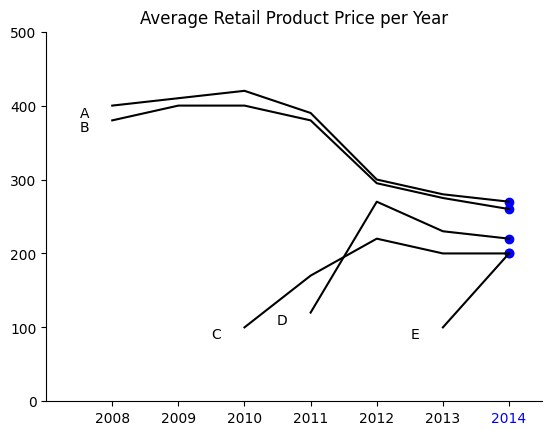

In [188]:
import matplotlib.pyplot as plt

# Data
years = np.array([2008, 2009, 2010, 2011, 2012, 2013, 2014])

data = {
    "A": [400, 410, 420, 390, 300, 280, 270],
    "B": [380, 400, 400, 380, 295, 275, 260],
    "C": [None, None, 100, 170, 220, 200, 200],
    "D": [None, None, None, 120, 270, 230, 220],
    "E": [None, None, None, None, None, 100, 200],}

plt.figure()

for label, values in data.items():
    y = np.array(values, dtype=np.float64)

    # plot lines in black
    plt.plot(years, y, color='black')

    # find valid points
    valid_idx = np.where(~np.isnan(y))[0]
    if len(valid_idx) > 0:
        first = valid_idx[0]
        last = valid_idx[-1]

        plt.scatter(years[last], y[last], color='blue')

        plt.text(years[first] - 0.35,
                 y[first] - 10,
                 label,
                 ha='right',
                 va='center')

plt.xlim(2007.0, 2014.5)
plt.ylim(0, 500)
plt.xticks(years)
plt.yticks(np.arange(0, 501, 100))

plt.title("Average Retail Product Price per Year")
plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

for tick_label in ax.get_xticklabels():
    if tick_label.get_text() == '2014':
        tick_label.set_color('blue')

plt.show()